# **NLP Assignment 4 – BERT Fine-Tuning**

**1. Install Required Libraries**

In [6]:
!pip install transformers datasets scikit-learn torch

**2. Import Libraries**

In [7]:
import pandas as pd
import numpy as np
import json
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import torch
from torch.utils.data import Dataset

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments

**3. Load Dataset**

In [8]:
import json

data = []

with open('/content/News_Category_Dataset_v3.json', 'r') as f:
    for i, line in enumerate(f):
        try:
            data.append(json.loads(line))
        except json.JSONDecodeError as e:
            print(f"Skipping malformed line {i+1}: {e}")

df = pd.DataFrame(data)

df.head()

Skipping malformed line 178543: Expecting property name enclosed in double quotes: line 1 column 109 (char 108)


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


**4. Data Preprocessing**

In [23]:
# Re-initialize df from original data to ensure 'headline' and 'short_description' columns are present
df = pd.DataFrame(data)

# Combine headline + short description
df['text'] = df['headline'] + " " + df['short_description']

# Drop missing values
df = df[['text', 'category']].dropna()

# Encode labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['label'] = le.fit_transform(df['category'])

df.head()

,text,category,label
0,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,35
1,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,35
2,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,5
3,The Funniest Tweets From Parents This Week (Se...,PARENTING,22
4,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,35


**5. Train / Validation / Test Split**

In [24]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42)

**6. Tokenization (BERT)**

In [25]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(list(val_texts), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True, max_length=128)

**7. Create PyTorch Dataset**

In [26]:
class NewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = NewsDataset(train_encodings, train_labels)
val_dataset = NewsDataset(val_encodings, val_labels)
test_dataset = NewsDataset(test_encodings, test_labels)

**8. Load Pre-trained BERT Model**

In [27]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(df['label'].unique())
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


**9. Training Argument**

In [5]:
!pip uninstall -y transformers accelerate -q
!pip install transformers accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 64.6 MB/s eta 0:00:00


In [28]:
import transformers
print(transformers.__version__)

5.0.0


In [29]:
import torch
print(torch.cuda.is_available())

True


In [30]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=50
)

**10. Evaluation Metrics**

In [31]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

**11. Trainer Setup**

In [32]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

**12. Train Model**

In [33]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.160528,1.113401,0.671614,0.661474,0.662146,0.671614


TrainOutput(global_step=17855, training_loss=1.3439746153785281, metrics={'train_runtime': 1753.0358, 'train_samples_per_second': 81.478, 'train_steps_per_second': 10.185, 'total_flos': 4733553229143552.0, 'train_loss': 1.3439746153785281, 'epoch': 1.0})

**13. Evaluate Model**

In [34]:
results = trainer.evaluate(test_dataset)
print(results)

{'eval_loss': 1.089963436126709, 'eval_accuracy': 0.6752730327639317, 'eval_f1': 0.665220500036086, 'eval_precision': 0.665795745416685, 'eval_recall': 0.6752730327639317, 'eval_runtime': 62.2419, 'eval_samples_per_second': 286.864, 'eval_steps_per_second': 35.86, 'epoch': 1.0}


**14. Confusion Matrix**

In [36]:
preds = trainer.predict(test_dataset)
y_pred = np.argmax(preds.predictions, axis=1)

cm = confusion_matrix(test_labels, y_pred)
print(cm)

[[ 76   7   2 ...   4   0   3]
 [  5  58   3 ...   6   2   0]
 [  1   0 176 ...   6   0   1]
 ...
 [  2   2   2 ... 134   3   0]
 [  0   2   0 ...   3 104   1]
 [  4   0   0 ...   1   2 163]]


**15. Confusion Matrix**

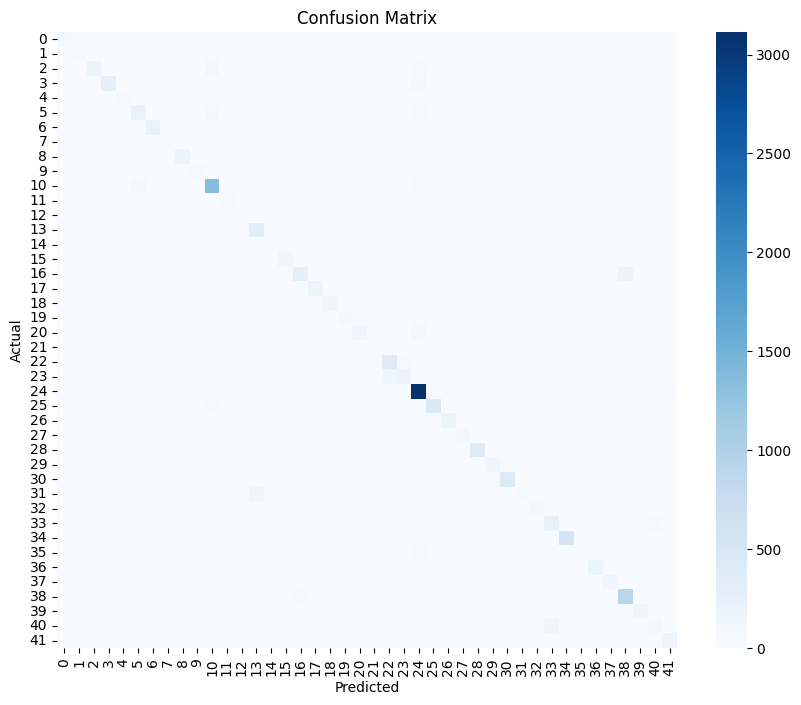

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# **EXPERIMENTS SECTION**

**Experiment 1: Freeze BERT Layers**

In [44]:
# Freeze DistilBERT layers
for param in model.distilbert.parameters():
    param.requires_grad = False

In [45]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.184045,1.184291,0.673967,0.669550,0.668624,0.673967


TrainOutput(global_step=17855, training_loss=0.78912745857399, metrics={'train_runtime': 599.5118, 'train_samples_per_second': 238.249, 'train_steps_per_second': 29.783, 'total_flos': 4733553229143552.0, 'train_loss': 0.78912745857399, 'epoch': 1.0})

In [46]:
result_frozen = trainer.evaluate()
print(result_frozen)

{'eval_loss': 1.1842914819717407, 'eval_accuracy': 0.67396661812479, 'eval_f1': 0.6695500819103329, 'eval_precision': 0.6686239298544967, 'eval_recall': 0.67396661812479, 'eval_runtime': 63.5358, 'eval_samples_per_second': 281.007, 'eval_steps_per_second': 35.13, 'epoch': 1.0}


**Experiment 2: Fine-tune last 2 layers**

In [40]:
# Freeze all layers first
for param in model.distilbert.parameters():
    param.requires_grad = False

# Unfreeze last 2 transformer layers
for name, param in model.distilbert.named_parameters():
    if "transformer.layer.4" in name or "transformer.layer.5" in name:
        param.requires_grad = True

In [42]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.142651,1.125941,0.674471,0.668494,0.667557,0.674471


TrainOutput(global_step=17855, training_loss=0.8833531052550159, metrics={'train_runtime': 919.8984, 'train_samples_per_second': 155.27, 'train_steps_per_second': 19.41, 'total_flos': 4733553229143552.0, 'train_loss': 0.8833531052550159, 'epoch': 1.0})

In [43]:
result_frozen = trainer.evaluate()
print(result_frozen)

{'eval_loss': 1.1259411573410034, 'eval_accuracy': 0.6744707068444046, 'eval_f1': 0.6684936257521342, 'eval_precision': 0.6675573579835691, 'eval_recall': 0.6744707068444046, 'eval_runtime': 63.0385, 'eval_samples_per_second': 283.224, 'eval_steps_per_second': 35.407, 'epoch': 1.0}


# **FINAL COMPARISON TABLE**

In [47]:
import pandas as pd

results = pd.DataFrame({
    "Experiment": [
        "Frozen DistilBERT",
        "Last 2 Layers Fine-Tuned",
        "Full Fine-Tuning"
    ],
    "Accuracy": [
        0.6739,
        0.6744,
        0.6716
    ],
    "F1 Score": [
        0.6695,
        0.6685,
        0.6614
    ],
    "Precision": [
        0.6686,
        0.6675,
        0.6621
    ],
    "Recall": [
        0.6739,
        0.6744,
        0.6716
    ]
})

results

,Experiment,Accuracy,F1 Score,Precision,Recall
0,Frozen DistilBERT,0.6739,0.6695,0.6686,0.6739
1,Last 2 Layers Fine-Tuned,0.6744,0.6685,0.6675,0.6744
2,Full Fine-Tuning,0.6716,0.6614,0.6621,0.6716


**Graph: Accuracy and F1 Score Comparison**

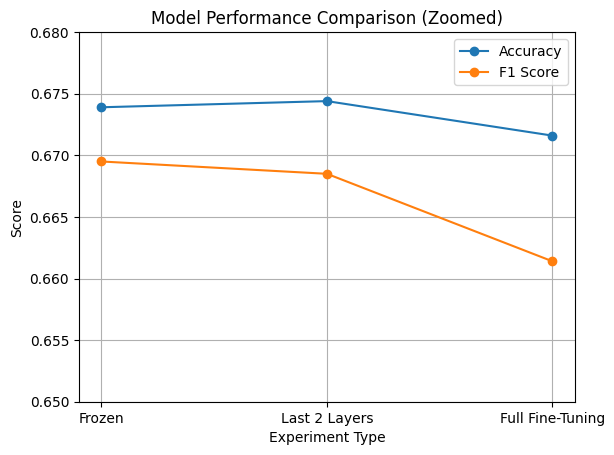

In [49]:
import matplotlib.pyplot as plt

experiments = ["Frozen", "Last 2 Layers", "Full Fine-Tuning"]
accuracy = [0.6739, 0.6744, 0.6716]
f1_scores = [0.6695, 0.6685, 0.6614]

plt.figure()

plt.plot(experiments, accuracy, marker='o', label="Accuracy")
plt.plot(experiments, f1_scores, marker='o', label="F1 Score")

plt.ylim(0.65, 0.68)

plt.title("Model Performance Comparison (Zoomed)")
plt.xlabel("Experiment Type")
plt.ylabel("Score")

plt.legend()
plt.grid()

plt.show()